In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [3]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [4]:
model_deep = keras.Sequential(
  [
    layers.Dense(
      3,
      activation="sigmoid",
      name="layer1",
      input_shape=(4,)
    ),

    layers.Dense(
      3,
      activation="sigmoid",
      name="layer2"
    ),

    layers.Dense(
      3,
      activation="sigmoid",
      name="layer3"
    ),

    layers.Dense(
      3,
      activation="sigmoid",
      name="layer4"
    ),
  ]
)

model_deep.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
y = model_deep(X)
print(y[149])

tf.Tensor([0.4726505  0.39458168 0.33575684], shape=(3,), dtype=float32)


In [6]:
optimizer_deep = tf.keras.optimizers.SGD(learning_rate=0.03)
loss_deep = tf.keras.losses.MeanSquaredError()

model_deep.compile(
  optimizer=optimizer_deep,
  loss=loss_deep
)

history_deep = model_deep.fit(
  X,
  Y,
  epochs=500
)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2298  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2296 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2294 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2293 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2291 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2289 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2287 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2286 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2284 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2283 
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2281 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2280 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2278 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2277 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2275 
Epoch 16/500
5/5 ━

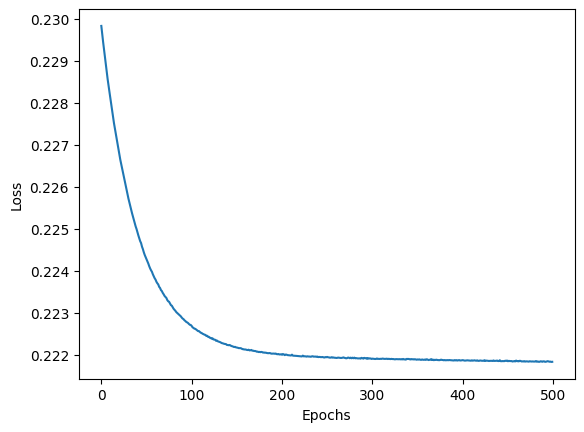

Loss final: 0.22183482348918915


In [7]:
plt.plot(history_deep.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

print("Loss final:", history_deep.history['loss'][-1])

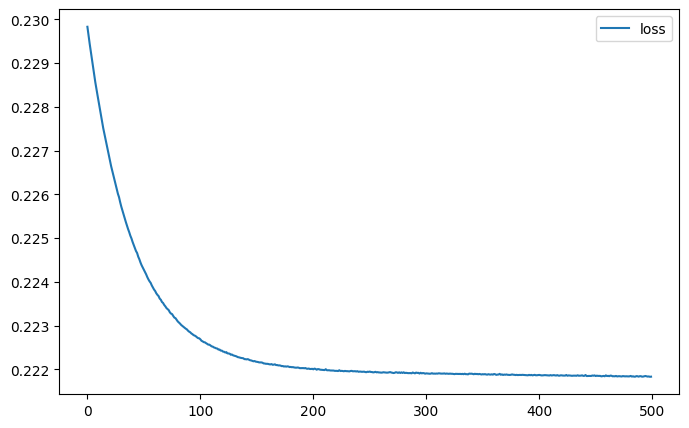

In [9]:
pd.DataFrame(history_deep.history).plot(figsize=(8,5))
plt.show()

In [10]:
model_deep.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([[0.3364593 , 0.33355546, 0.3341836 ]], dtype=float32)